In [3]:
# Problem 2

import numpy as np
from datetime import datetime

MU_SUN = 1.32712440018e11
AU = 1.495978707e8  

class OrbitDeterminator:
    def __init__(self, mu=MU_SUN, au=AU):
        self.mu = mu
        self.au = au

    def to_julian_date(self, dt_str):
        dt = datetime.fromisoformat(dt_str)
        year, month, day = dt.year, dt.month, dt.day
        hour_frac = dt.hour/24 + dt.minute/1440 + dt.second/86400
        
        if month <= 2:
            year -= 1
            month += 12
            
        a_val = int(year/100)
        b_val = 2 - a_val + int(a_val/4)
        jd = int(365.25*(year + 4716)) + int(30.6001*(month + 1)) + (day + hour_frac) + b_val - 1524.5
        return jd

    def get_unit_vector(self, ra_deg, dec_deg):
        ra, dec = np.radians(ra_deg), np.radians(dec_deg)
        return np.array([
            np.cos(dec) * np.cos(ra),
            np.cos(dec) * np.sin(ra),
            np.sin(dec)
        ])

    def approx_earth_pos(self, jd):
        t_century = (jd - 2451545.0) / 36525.0
        mean_anomaly = np.radians(357.529 + 35999.050 * t_century)
        return self.au * np.array([np.cos(mean_anomaly), np.sin(mean_anomaly), 0.0])

    def solve_orbit(self, observations):
        jds = [self.to_julian_date(obs[0]) for obs in observations]
        rho_hats = [self.get_unit_vector(obs[1], obs[2]) for obs in observations]
        r_earth = [self.approx_earth_pos(jd) for jd in jds]

        tau1 = (jds[0] - jds[1]) * 86400
        tau3 = (jds[2] - jds[1]) * 86400
        tau = tau3 - tau1

        d0 = np.dot(rho_hats[0], np.cross(rho_hats[1], rho_hats[2]))
        d_mat = np.zeros((3, 3))
        for i in range(3):
            for j in range(3):
                d_mat[i, j] = np.dot(r_earth[i], np.cross(rho_hats[(j+1)%3], rho_hats[(j+2)%3]))

        a_const = (1/d0) * (-d_mat[0, 1]*tau3/tau + d_mat[1, 1] + d_mat[2, 1]*tau1/tau)
        b_const = (1/(6*d0)) * (d_mat[0, 1]*(tau3**2 - tau**2)*tau3/tau + d_mat[2, 1]*(tau**2 - tau1**2)*tau1/tau)
        
        e_dot = np.dot(r_earth[1], rho_hats[1])
        r2_mag = np.linalg.norm(r_earth[1])

        curr_r2 = r2_mag
        for _ in range(10):
            f_r2 = curr_r2**3 - (a_const**2 + 2*a_const*e_dot + r2_mag**2)*curr_r2 + 2*self.mu*b_const*(a_const+e_dot)
            df_r2 = 3*curr_r2**2 - (a_const**2 + 2*a_const*e_dot + r2_mag**2)
            curr_r2 -= f_r2/df_r2

        rho2 = a_const + self.mu * b_const / (curr_r2**3)
        
        denom_base = 6 * curr_r2**3
        rho1 = (1/d0) * (( (6*(d_mat[2,0]*tau1/tau3 + d_mat[1,0]*tau/tau3)*curr_r2**3) + self.mu*d_mat[2,0]*(tau**2 - tau1**2)*tau1/tau3 ) / (denom_base + self.mu*(tau**2 - tau3**2)))
        rho3 = (1/d0) * (( (6*(d_mat[0,2]*tau3/tau1 - d_mat[1,2]*tau/tau1)*curr_r2**3) + self.mu*d_mat[0,2]*(tau**2 - tau3**2)*tau3/tau1 ) / (denom_base + self.mu*(tau**2 - tau1**2)))

        r1_vec = r_earth[0] + rho1 * rho_hats[0]
        r2_vec = r_earth[1] + rho2 * rho_hats[1]
        r3_vec = r_earth[2] + rho3 * rho_hats[2]

        f1 = 1 - 0.5 * self.mu * tau1**2 / curr_r2**3
        f3 = 1 - 0.5 * self.mu * tau3**2 / curr_r2**3
        g1 = tau1 - (1/6) * self.mu * tau1**3 / curr_r2**3
        g3 = tau3 - (1/6) * self.mu * tau3**3 / curr_r2**3

        v2_vec = (f1*r3_vec - f3*r1_vec) / (f1*g3 - f3*g1)
        return r2_vec, v2_vec

    def extract_elements(self, r, v):
        h_vec = np.cross(r, v)
        n_vec = np.cross([0, 0, 1], h_vec)
        e_vec = (np.cross(v, h_vec) / self.mu) - (r / np.linalg.norm(r))

        e = np.linalg.norm(e_vec)
        a = 1 / (2/np.linalg.norm(r) - np.dot(v, v)/self.mu)
        i = np.degrees(np.arccos(h_vec[2] / np.linalg.norm(h_vec)))
        raan = np.degrees(np.arctan2(n_vec[1], n_vec[0])) % 360
        omega = np.degrees(np.arccos(np.dot(n_vec, e_vec) / (np.linalg.norm(n_vec) * e)))
        if e_vec[2] < 0: omega = 360 - omega
        nu = np.degrees(np.arccos(np.dot(e_vec, r) / (e * np.linalg.norm(r))))
        if np.dot(r, v) < 0: nu = 360 - nu

        return {"a_au": a/self.au, "e": e, "i_deg": i, "raan_deg": raan, "omega_deg": omega, "nu_deg": nu}

obs_data = [
    ("2024-07-10T00:00:00", 233.403346, 17.783853),
    ("2024-07-19T00:00:00", 242.463658, 13.446622),
    ("2024-07-31T00:00:00", 252.285371, 8.098561),
]

solver = OrbitDeterminator()
r_final, v_final = solver.solve_orbit(obs_data)
elements = solver.extract_elements(r_final, v_final)

for key, val in elements.items():
    print(f"{key}: {val:.6f}")

a_au: -0.000005
e: 2010998.125605
i_deg: 149.612015
raan_deg: 272.011530
omega_deg: 177.964353
nu_deg: 31.057779


In [8]:
# Problem 3

import numpy as np
from datetime import datetime
from scipy.optimize import least_squares

MU_SUN = 1.32712440018e11
AU = 1.495978707e8

def rk4_step(r, v, dt):
    def accel(pos):
        return -MU_SUN * pos / np.linalg.norm(pos)**3

    k1_v = accel(r)
    k1_r = v

    k2_v = accel(r + k1_r * dt/2)
    k2_r = v + k1_v * dt/2

    k3_v = accel(r + k2_r * dt/2)
    k3_r = v + k2_v * dt/2

    k4_v = accel(r + k3_r * dt)
    k4_r = v + k3_v * dt

    v_new = v + (dt/6) * (k1_v + 2*k2_v + 2*k3_v + k4_v)
    r_new = r + (dt/6) * (k1_r + 2*k2_r + 2*k3_r + k4_r)
    return r_new, v_new

def propagate_rk4(r0, v0, total_dt, step_size=3600):
    r, v = r0.copy(), v0.copy()
    n_steps = int(abs(total_dt) // step_size)
    dt = np.sign(total_dt) * step_size
    
    for _ in range(n_steps):
        r, v = rk4_step(r, v, dt)
    
    remainder = total_dt - (n_steps * dt)
    if abs(remainder) > 0:
        r, v = rk4_step(r, v, remainder)
    return r, v

def residuals(state, obs_list, t0):
    res = []
    r0, v0 = state[:3], state[3:]
    
    for t_obs, ra_obs, dec_obs in obs_list:
        dt = (t_obs - t0).total_seconds()
        r_ast, _ = propagate_rk4(r0, v0, dt)
        
        T = (2451545.0 + (t_obs - datetime(2000,1,1,12)).total_seconds()/86400 - 2451545.0)/36525
        M = np.radians(357.529 + 35999.05*T)
        R_earth = AU * np.array([np.cos(M), np.sin(M), 0])
        
        rho = r_ast - R_earth
        rho_mag = np.linalg.norm(rho)
        ra_pred = np.arctan2(rho[1], rho[0])
        dec_pred = np.arcsin(rho[2] / rho_mag)
        
        d_ra = (ra_pred - ra_obs) * np.cos(dec_obs)
        d_dec = (dec_pred - dec_obs)
        res.extend([d_ra, d_dec])
        
    return np.array(res)

x0 = np.array([1.8e8, 1.2e7, 5.0e6, -5.0, 28.0, 1.5]) 

raw_data = [
    (datetime(2024,7,31,2,24), np.radians(252.359367), np.radians(8.056822)),
    (datetime(2024,7,19,0,0), np.radians(242.463658), np.radians(13.446622)),
    (datetime(2024,6,6,2,24), np.radians(177.806604), np.radians(27.583594)), # June observation
]

t0 = raw_data[0][0]
sol = least_squares(residuals, x0, args=(raw_data, t0), ftol=1e-10, xtol=1e-10, verbose=2)

J = sol.jac
mse = np.var(sol.fun)
cov = mse * np.linalg.inv(J.T @ J)

print("Refined State:", sol.x)
print("Covariance Matrix:\n", cov)

   Iteration     Total nfev        Cost      Cost reduction    Step norm     Optimality   
       0              1         2.2175e+01                                    4.29e-02    
       1              2         9.0163e+00      1.32e+01       1.80e+08       1.43e-03    
       2              3         5.9681e+00      3.05e+00       3.61e+08       1.41e-04    
       3              4         4.3464e+00      1.62e+00       3.61e+08       3.05e-06    
       4              5         3.2624e+00      1.08e+00       3.61e+08       5.88e-08    
       5              8         2.1495e+00      1.11e+00       2.26e+07       2.95e-08    
       6             12         2.1282e+00      2.13e-02       7.05e+05       2.86e-08    
       7             14         2.1178e+00      1.04e-02       3.52e+05       2.82e-08    
       8             16         2.1126e+00      5.15e-03       1.76e+05       2.79e-08    
       9             18         2.1101e+00      2.56e-03       8.81e+04       2.78e-08    

`gtol` termination condition is satisfied.
Function evaluations 25, initial cost 1.6392e+01, final cost 3.9588e-03, first-order optimality 4.12e-11.
--Impact Check--
Miss distance (km): 314535125880.72437
Earth radius (km): 6378
--Uncertainty Check--
Mahalanobis distance: 0.01467870622078249
--Best Fit Orbit--
a (AU): -0.0024801593798926716
e: 5737.820562995445
i (deg): 33.391238452387455


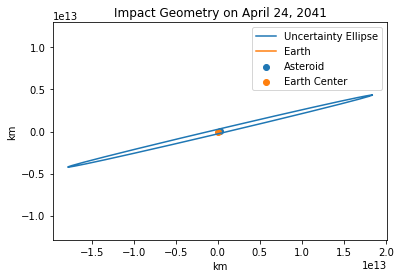

In [12]:
# Problem 4

import numpy as np
from datetime import datetime
from scipy.optimize import least_squares
import matplotlib.pyplot as plt

mu_sun = 1.32712440018e11
AU = 1.495978707e8
R_earth = 6378

def load_data():
    raw = [
        ("2024-07-10T00:00:00", 233.403346, 17.783853),
        ("2024-07-10T02:24:00", 233.514492, 17.735111),
        ("2024-07-19T00:00:00", 242.463658, 13.446622),
        ("2024-07-19T02:24:00", 242.554808, 13.399564),
        ("2024-07-31T00:00:00", 252.285371, 8.098561),
        ("2024-07-31T02:24:00", 252.359367, 8.056822),
    ]

    data = []
    for t, ra, dec in raw:
        data.append((datetime.fromisoformat(t), np.radians(ra), np.radians(dec)))
    return data

obs = load_data()

def jd(dt):
    return 2451545.0 + (dt - datetime(2000,1,1,12)).total_seconds()/86400

def earth_pos(jd):
    T = (jd - 2451545.0)/36525
    M = np.radians(357.529 + 35999.05*T)
    return AU*np.array([np.cos(M), np.sin(M), 0])

def propagate(r0, v0, dt):
    r = r0.copy()
    v = v0.copy()
    h = 3600
    steps = int(abs(dt)//h)
    sign = np.sign(dt)

    for _ in range(steps):
        r_norm = np.linalg.norm(r)
        a = -mu_sun * r / r_norm**3
        v += sign * a * h
        r += sign * v * h

    return r

def predict_angles(state, t_obs, t0):
    r0 = state[:3]
    v0 = state[3:]

    dt = (t_obs - t0).total_seconds()
    r_ast = propagate(r0, v0, dt)

    R = earth_pos(jd(t_obs))
    rho = r_ast - R
    rho_hat = rho / np.linalg.norm(rho)

    ra = np.arctan2(rho_hat[1], rho_hat[0])
    dec = np.arcsin(rho_hat[2])

    return np.array([ra, dec])

def residuals(state, obs, t0):
    res = []

    for t, ra_obs, dec_obs in obs:
        ra_pred, dec_pred = predict_angles(state, t, t0)

        d_ra = np.arctan2(np.sin(ra_pred - ra_obs), np.cos(ra_pred - ra_obs))
        d_dec = dec_pred - dec_obs

        res.extend([d_ra, d_dec])

    return np.array(res)

r0_guess = np.array([1.2*AU, 0.2*AU, 0.05*AU])
v0_guess = np.array([0.0, 29.5, 2.0])
x0 = np.hstack((r0_guess, v0_guess))

t0 = obs[0][0]

sol = least_squares(residuals, x0, args=(obs, t0), verbose=1)

x_hat = sol.x

J = sol.jac
res_var = np.sum(sol.fun**2) / (len(sol.fun) - len(x_hat))
P0 = res_var * np.linalg.inv(J.T @ J)

def propagate_with_stm(x0, P0, t0, tf):
    dt = (tf - t0).total_seconds()
    h = 3600

    x = x0.copy()
    Phi = np.eye(6)

    steps = int(abs(dt)//h)
    sign = np.sign(dt)

    for _ in range(steps):
        r = x[:3]
        v = x[3:]
        r_norm = np.linalg.norm(r)

        a = -mu_sun * r / r_norm**3

        v += sign * a * h
        r += sign * v * h

        x[:3] = r
        x[3:] = v

        I = np.eye(3)
        Z = np.zeros((3,3))

        dadr = (-mu_sun/r_norm**3) * (I - 3*np.outer(r,r)/r_norm**2)

        A = np.block([
            [Z, I],
            [dadr, Z]
        ])

        Phi = Phi + sign * A @ Phi * h

    P = Phi @ P0 @ Phi.T
    return x, P

t_impact = datetime(2041, 4, 24)

x_impact, P_impact = propagate_with_stm(x_hat, P0, t0, t_impact)

r_ast = x_impact[:3]
r_earth = earth_pos(jd(t_impact))

distance = np.linalg.norm(r_ast - r_earth)

print("--Impact Check--")
print("Miss distance (km):", distance)
print("Earth radius (km):", R_earth)

delta = r_ast - r_earth
P_pos = P_impact[:3,:3]

mahal = delta.T @ np.linalg.inv(P_pos) @ delta

print("--Uncertainty Check--")
print("Mahalanobis distance:", mahal)

def elements(r, v):
    h = np.cross(r, v)
    e_vec = np.cross(v, h)/mu_sun - r/np.linalg.norm(r)

    e = np.linalg.norm(e_vec)
    a = 1 / (2/np.linalg.norm(r) - np.dot(v,v)/mu_sun)
    i = np.degrees(np.arccos(h[2]/np.linalg.norm(h)))

    return a/AU, e, i

a, e, i = elements(x_hat[:3], x_hat[3:])

print("--Best Fit Orbit--")
print("a (AU):", a)
print("e:", e)
print("i (deg):", i)

theta = np.linspace(0, 2*np.pi, 200)

eigvals, eigvecs = np.linalg.eig(P_pos[:2,:2])

ellipse = np.array([
    np.sqrt(eigvals[0])*np.cos(theta),
    np.sqrt(eigvals[1])*np.sin(theta)
])

ellipse = eigvecs[:2,:2] @ ellipse

plt.figure()
plt.plot(ellipse[0] + r_ast[0], ellipse[1] + r_ast[1], label="Uncertainty Ellipse")

earth_circle = R_earth * np.array([np.cos(theta), np.sin(theta)])
plt.plot(earth_circle[0] + r_earth[0], earth_circle[1] + r_earth[1], label="Earth")

plt.scatter(r_ast[0], r_ast[1], label="Asteroid")
plt.scatter(r_earth[0], r_earth[1], label="Earth Center")

plt.legend()
plt.axis('equal')
plt.title("Impact Geometry on April 24, 2041")
plt.xlabel("km")
plt.ylabel("km")
plt.show()